# **Губанова В.Е.**
# **РТ5-61Б**
# **Вариант 5**

# Рубежный контроль №1

Тема: Технологии разведочного анализа и обработки данных.

Задача №1.
Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель.

Импортируем библиотеки pandas, matplotlib, seaborn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model, metrics, model_selection

Загрузка и первичный просмотр данных

In [2]:
data = pd.read_csv('Admission_Predict.csv')

data.head()

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


Проверка пропусков в данных

In [4]:
data.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


Пропуски отсутствуют, поэтому удаление строк или столбцов не требуется

Удалим столбец Serial No., так как он не несёт полезной информации.

In [5]:
data = data.drop(columns=['Serial No.'])

data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65


## Корреляционный анализ

In [6]:
corr_matrix = data.corr()

corr_matrix

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
GRE Score,1.000000,0.835977,0.668976,0.612831,0.557555,0.833060,0.580391,0.802610
TOEFL Score,0.835977,1.000000,0.695590,0.657981,0.567721,0.828417,0.489858,0.791594
University Rating,0.668976,0.695590,1.000000,0.734523,0.660123,0.746479,0.447783,0.711250
SOP,0.612831,0.657981,0.734523,1.000000,0.729593,0.718144,0.444029,0.675732
LOR,0.557555,0.567721,0.660123,0.729593,1.000000,0.670211,0.396859,0.669889
CGPA,0.833060,0.828417,0.746479,0.718144,0.670211,1.000000,0.521654,0.873289
Research,0.580391,0.489858,0.447783,0.444029,0.396859,0.521654,1.000000,0.553202
Chance of Admit,0.802610,0.791594,0.711250,0.675732,0.669889,0.873289,0.553202,1.000000


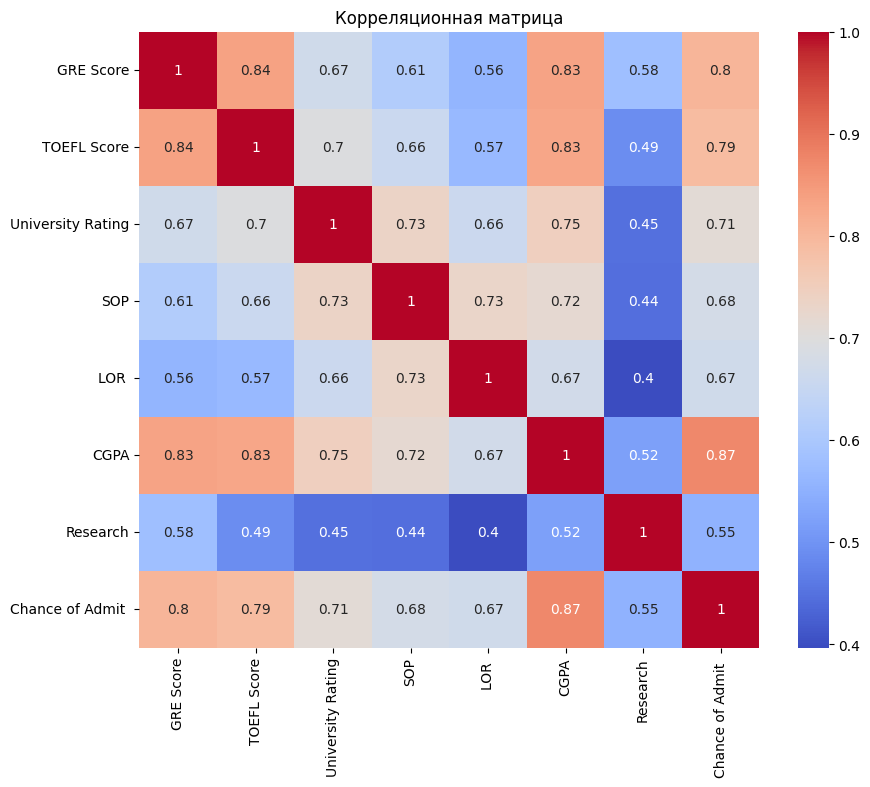

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

Рассмотрим корреляцию признаков с Chance of Admit

In [9]:
corr_target = corr_matrix['Chance of Admit '].sort_values(ascending=False)

corr_target

,Chance of Admit
Chance of Admit,1.000000
CGPA,0.873289
GRE Score,0.802610
TOEFL Score,0.791594
University Rating,0.711250
SOP,0.675732
LOR,0.669889
Research,0.553202


Наиболее сильную корреляцию с целевой переменной имеют:

- CGPA
- GRE Score
- TOEFL Score

Это означает, что именно эти признаки вносят наибольший вклад в модель.

Также наблюдается высокая корреляция между самими признаками (например, GRE и TOEFL), что указывает на возможную мультиколлинеарность.

## Выводы

1. Пропуски в данных отсутствуют.
2. Набор данных подходит для построения моделей машинного обучения.
3. Наиболее значимые признаки:
   - CGPA
   - GRE Score
   - TOEFL Score
4. Присутствует мультиколлинеарность между признаками.
5. Рекомендуемые модели:
   - Линейная регрессия (с регуляризацией)
   - Random Forest
   - Gradient Boosting